In [1]:
%matplotlib inline


# 从零构建图像分类模型

本章着重介绍如何使用 PyTorch 在自己收集的图像数据集上训练深度学习模型，主要方法是使用 torchvision 中提供的在 ImageNet 上预训练好的图像分类模型，分别介绍以微调的方式和将其作为特征提取器的方式来构建自己的深度学习模型。本章将从四个方面讲解：预训练模型的基本原理、准备模型、训练模型和测试和评估模型。


在深度学习的实际应用中，很少会从头去训练一个网络，尤其是当没有大量数据的时候。即便拥有大量数据，从头训练一个网络也很耗时，因为在大数据集上所构建的网络通常模型参数量很大，训练成本大。所以在构建深度学习应用时，通常会使用**预训练模型**。要了解预训练模型的原理，首先需要理解 PyTorch 是如何保存和加载模型的，所以下面介绍状态字典。


目前有两种使用预训练模型的方法：

-  **微调**: 微调（Fine tuning）是指在创建模型时，使用预训练的模型来初始化网络，而非随机初始化网络，并且权重可以随着训练的进行而发生改变。
-  **固定参数**: 固定模型中除了最后的全连接层外的其他所有层。最后的全连接层被替换成一个新的随机初始化的层，只有这个新的层会被训练（只有这层参数会在反向传播时更新）


In [2]:
# License: BSD
# Author: Sasank Chilamkurthy

from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

cudnn.benchmark = True
plt.ion()   # interactive mode

## 加载数据集

要解决的问题是训练一个模型来分类蚂蚁ants和蜜蜂bees。

ants和bees各有约120张训练图片。

每个类有75张验证图片。从零开始在 如此小的数据集上进行训练通常是很难泛化的。

由于我们使用迁移学习，模型的泛化能力会相当好。

该数据集是imagenet的一个非常小的子集。从[此处](https://download.pytorch.org/tutorial/hymenoptera_data.zip)下载数据。在当前目录新建`data`目录，并解压包里的`hymenoptera_data`目录放到`data`目录下。


In [4]:
# 在训练集上：扩充、归一化
# 在验证集上：归一化
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

### 使用matplotlib可视化数据

为了观察到扩充后的数据情况，需要借助 matplotlib 来打印图片和图片的类别。编写一个
imshow 函数，它接收一个 batch 的图片，并按从左到右的顺序展示图片的类别。



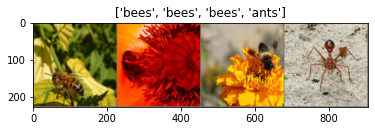

In [5]:
def imshow(inp, title=None): 
    # 可视化一组 Tensor 的图片
    inp = inp.numpy().transpose((1, 2, 0)) 
    mean = np.array([0.485, 0.456, 0.406]) 
    std = np.array([0.229, 0.224, 0.225]) 
    inp = std * inp + mean 
    inp = np.clip(inp, 0, 1) 
    plt.imshow(inp) 
    if title is not None: 
        plt.title(title) 
    plt.pause(0.001) # 暂停一会儿，为了将图片显示出来
# 获取一批训练数据
inputs, classes = next(iter(dataloaders['train'])) 
# 批量制作网格
out = torchvision.utils.make_grid(inputs) 
imshow(out, title=[class_names[x] for x in classes]) 

## 开始训练

为了方便后续使用预训练模型，可以将训练过程写成一个函数，向该函数中传入网络模型、损失函数等必要对象后，在该数据集上训练模型并返回在验证集上最高的准确率和对应的模型对
象。


In [7]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25): 
    """ 训练模型，并返回在验证集上的最佳模型和准确率 
    Args: 
    - model(nn.Module): 要训练的模型 
    - criterion: 损失函数 
    - optimizer(optim.Optimizer): 优化器 
    - scheduler: 学习率调度器 
    - num_epochs(int): 最大 epoch 数 
    Return: 
    - model(nn.Module): 最佳模型 
    - best_acc(float): 最佳准确率 
    """
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # 训练集和验证集交替进行前向传播
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # 设置为训练模式，可以更新网络参数
            else:
                model.eval()   # 设置为预估模式，不可更新网络参数

            running_loss = 0.0
            running_corrects = 0

            # 遍历数据集
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # 清空梯度，避免累加了上一次的梯度
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # 正向传播
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # 反向传播且仅在训练阶段进行优化
                    if phase == 'train':
                        loss.backward() # 反向传播
                        optimizer.step()

                # 统计loss、准确率
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # 发现了更优的模型，记录起来
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # 加载训练的最好的模型
    model.load_state_dict(best_model_wts)
    return model

### 观察模型预测结果

使用之前 imshow() 函数可以查看 DataLoader 打包的一个 batch 的图片，为了查看模
型效果，下述代码实现了传入模型，并且可视化模型的预测结果。



In [8]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

## 使用torchvision微调模型

加载预训练模型，并将最后一个全连接层重置



In [9]:
model = models.resnet18(pretrained=True) # 加载预训练模型
num_ftrs = model.fc.in_features # 获取低级特征维度 
model.fc = nn.Linear(num_ftrs, 2) # 替换新的输出层 
model = model.to(device) 
# 交叉熵作为损失函数 
criterion = nn.CrossEntropyLoss() 
# 所有参数都参加训练 
optimizer_ft = optim.SGD(model.parameters(), lr=0.001, momentum=0.9) 
# 每过 7 个 epoch 将学习率变为原来的 0.1 
scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /Users/f/.cache/torch/checkpoints/resnet18-5c106cde.pth
100.0%


### 训练并预估

使用CPU训练的话，`num_epochs=25` 时会花费15~25分钟，如果用GPU的话，少于1分钟就可以完成

这里为了演示把epoch调小了


In [10]:
model_ft = train_model(model, criterion, optimizer_ft, 
 scheduler, num_epochs=3) # 开始训练 

Epoch 0/2
----------
train Loss: 0.5284 Acc: 0.7049
val Loss: 0.1722 Acc: 0.9281

Epoch 1/2
----------
train Loss: 0.3470 Acc: 0.8320
val Loss: 0.4315 Acc: 0.8366

Epoch 2/2
----------
train Loss: 0.6101 Acc: 0.7664
val Loss: 0.3918 Acc: 0.8758

Training complete in 3m 59s
Best val Acc: 0.928105


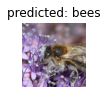

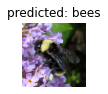

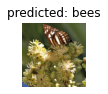

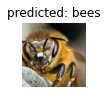

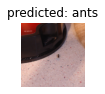

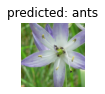

In [11]:
visualize_model(model_ft)

## 固定模型的参数

微调预训练模型，需要修改模型的内部结构，使其符合具体任务。模型所用框架不一样，在
将其他框架编写的模型迁移到 PyTorch 中时，无法使它们兼容。此时可以采取 Pipeline 形式将预训
练模型的参数固定，或者说将前一个模型的输出保存下来，将该输出作为 PyTorch 模型的输入。

采取这种思路，我们可以将模型除了输出层之外的所有层看成一个特征提取器。在训练模型
时，这些层的权重不参与训练，不可优化。在 PyTorch 中将权重设置为不可训练，只需将 `requires_grad` 设置为 False 即可。例如，下述代码可以将 ResNet18 的所有层设置为不可训练。



In [11]:
model_conv = torchvision.models.resnet18(pretrained=True) # 加载预训练模型
for param in model_conv.parameters(): # 锁定模型所有参数
    param.requires_grad = False

num_ftrs = model_conv.fc.in_features  # 获取低级特征维度
model_conv.fc = nn.Linear(num_ftrs, 2) # 替换新的输出层

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# 只有最后一层全连接层fc，参加训练
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# 每过 7 个 epoch 将学习率变为原来的 0.1 
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

### 训练并预估

使用CPU训练的话，只需要微调模型的一半时间，（如果`num_epochs=25`）也就是10分钟左右。因为大部分模型参数都不用计算梯度




In [13]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=3)

Epoch 0/2
----------
train Loss: 0.5947 Acc: 0.7049
val Loss: 0.2497 Acc: 0.9150

Epoch 1/2
----------
train Loss: 0.5512 Acc: 0.7869
val Loss: 0.3787 Acc: 0.8497

Epoch 2/2
----------
train Loss: 0.5481 Acc: 0.7500
val Loss: 0.1938 Acc: 0.9608

Training complete in 1m 16s
Best val Acc: 0.960784


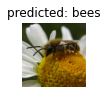

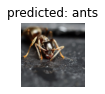

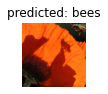

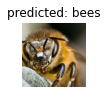

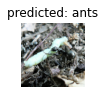

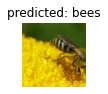

In [14]:
visualize_model(model_conv)

plt.ioff()
plt.show()